<a href="https://colab.research.google.com/github/Amelia039/prosaindata/blob/gh-pages/pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Pipelines

## Hasil Pipelines



*   Disini saya hanya bisa menggabungkan 3 tabel dari mysql local, postgres, dan elephantSql, karena SQL Server saya masih ada problem

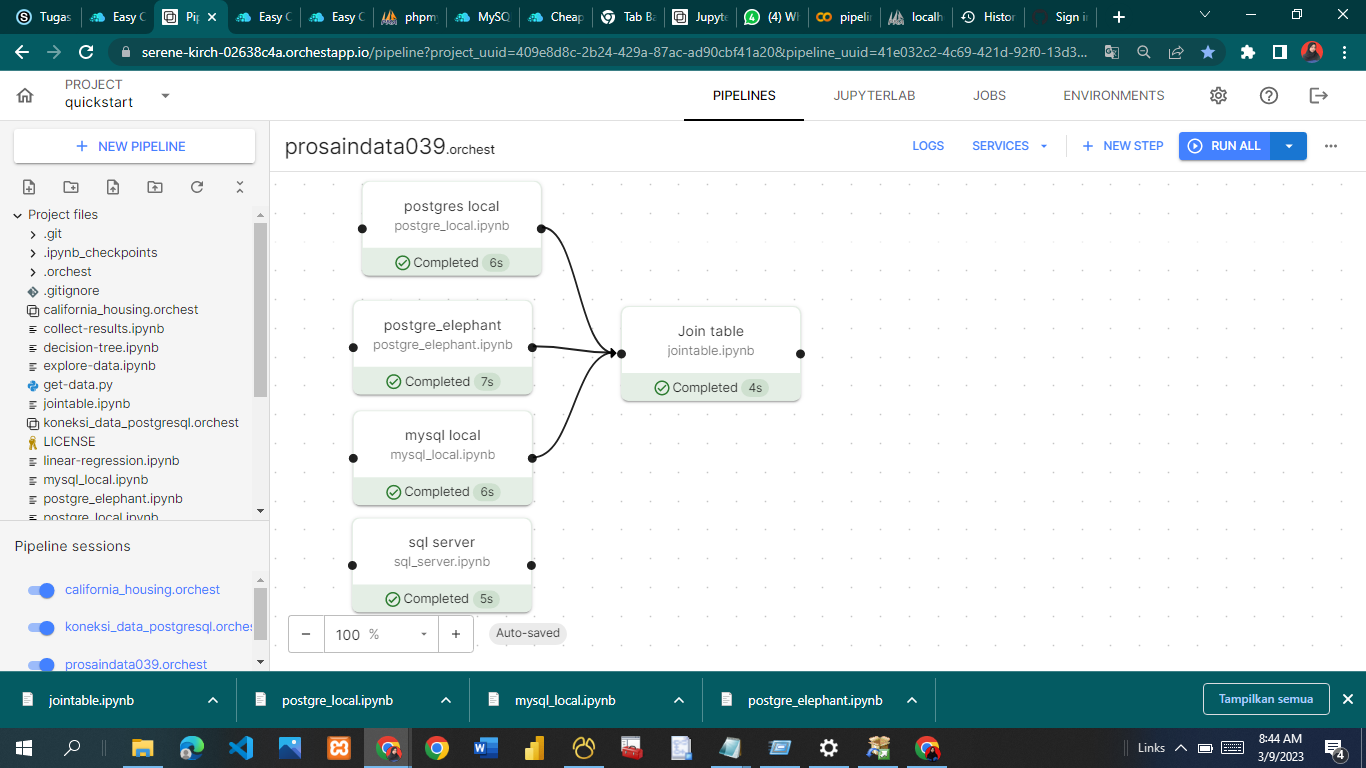



In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/prosaindata

/content/drive/MyDrive/prosaindata


## Mengambil data tabel petal length dari Mysql 

In [ ]:
import mysql.connector
import pandas as pd
import orchest
db = mysql.connector.connect(
  host="mysql-114634-0.cloudclusters.net",
  port="10022",
  user="admin",
  passwd="URBjxdfS",
  database  = "prosaindata039"
)

def postgresql_to_dataframe(select_query, column_names):
    """
    Tranform a SELECT query into a pandas dataframe
    """
    cursor = db.cursor()
    try:
        cursor.execute(select_query)
    except (Exception, psycopg2.DatabaseError) as error:
        print("Error: %s" % error)
        cursor.close()
        return 1
    
    # Naturally we get a list of tupples
    tupples = cursor.fetchall()
    cursor.close()
    
    # We just need to turn it into a pandas dataframe
    df = pd.DataFrame(tupples, columns=column_names)
    return df

# Connect to the database
column_names = ["id","petallength"]
df = postgresql_to_dataframe("select * from petallength", column_names)
print(df)

      id petallength
0      1         1.4
1      2         1.4
2      3         1.3
3      4         1.5
4      5         1.4
..   ...         ...
145  146         5.2
146  147         5.0
147  148         5.2
148  149         5.4
149  150         5.1

[150 rows x 2 columns]


## Mengambil data tabel sepal length dari postgre local

In [ ]:
import psycopg2
import pandas as pd
import orchest
# Connection parameters, yours will be different
param_dic = {
    "host"      : "postgresql-114632-0.cloudclusters.net",
    "database"  : "prosaindata039",
    "port"  : "19217",
    "user"      : "Amel",
    "password"  : "amelnur99"
}
def connect(params_dic):
    """ Connect to the PostgreSQL database server """
    conn = None
    try:
        # connect to the PostgreSQL server
        print('Connecting to the PostgreSQL database...')
        conn = psycopg2.connect(**params_dic)
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
    print("Connection successful")
    return conn

def postgresql_to_dataframe(conn, select_query, column_names):
    """
    Tranform a SELECT query into a pandas dataframe
    """
    cursor = conn.cursor()
    try:
        cursor.execute(select_query)
    except (Exception, psycopg2.DatabaseError) as error:
        print("Error: %s" % error)
        cursor.close()
        return 1
    
    # Naturally we get a list of tupples
    tupples = cursor.fetchall()
    cursor.close()
    
    # We just need to turn it into a pandas dataframe
    df = pd.DataFrame(tupples, columns=column_names)
    return df

# Connect to the database
conn = connect(param_dic)

column_names = ["id","sepallength"]

df = postgresql_to_dataframe(conn, "select * from sepallength", column_names)
print(df)

Connecting to the PostgreSQL database...


Connection successful
      id sepallength
0      1         5.1
1      2         4.9
2      3         4.7
3      4         4.6
4      5         5.0
..   ...         ...
145  146         6.7
146  147         6.3
147  148         6.5
148  149         6.2
149  150         5.9

[150 rows x 2 columns]


## Mengambil data sepal width dari elephanSQL

In [ ]:
import psycopg2
import pandas as pd
import orchest
# Connection parameters, yours will be different
param_dic = {
    "host"      : "floppy.db.elephantsql.com",
    "database"  : "qiymmgst",
    "user"      : "qiymmgst",
    "password"  : "vbkx8riGfZZNSkARnPAv-FUiy0M7Biv5"
}
def connect(params_dic):
    """ Connect to the PostgreSQL database server """
    conn = None
    try:
        # connect to the PostgreSQL server
        print('Connecting to the PostgreSQL database...')
        conn = psycopg2.connect(**params_dic)
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
        sys.exit(1) 
    print("Connection successful")
    return conn

def postgresql_to_dataframe(conn, select_query, column_names):
    """
    Tranform a SELECT query into a pandas dataframe
    """
    cursor = conn.cursor()
    try:
        cursor.execute(select_query)
    except (Exception, psycopg2.DatabaseError) as error:
        print("Error: %s" % error)
        cursor.close()
        return 1
    
    # Naturally we get a list of tupples
    tupples = cursor.fetchall()
    cursor.close()
    
    # We just need to turn it into a pandas dataframe
    df = pd.DataFrame(tupples, columns=column_names)
    return df

# Connect to the database
conn = connect(param_dic)

column_names = ["id","sepal_w"]

df = postgresql_to_dataframe(conn, "select * from sepalwidth", column_names)
print(df)

Connecting to the PostgreSQL database...


Connection successful


      id sepal_w
0      1     3.5
1      2     3.0
2      3     3.2
3      4     3.1
4      5     3.6
..   ...     ...
145  146     3.0
146  147     2.5
147  148     3.0
148  149     3.4
149  150     3.0

[150 rows x 2 columns]


## Menggabungkan data sepallength, sepalwidth dan petallength

In [ ]:
import pandas
import orchest
# Retrieve the data from the previous step.
data = orchest.get_inputs()
datasepallength = data["sepallength"]
datasepalwidth = data["sepalwidth"]
datapetallength = data["petallength"]
#datapetalwidth = data["datapetalwidth-class"]
alldata = pandas.concat((datasepallength, datasepalwidth,datapetallength), axis = 1)
alldata = alldata.drop(columns=['id'])
alldata

,sepallength,sepal_w,petallength
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4
...,...,...,...
145,6.7,3.0,5.2
146,6.3,2.5,5.0
147,6.5,3.0,5.2
148,6.2,3.4,5.4
